# ⚽ Hands-on Mini Exercise: Discovering Tactical Patterns

### 🎯 Goal
In this exercise, you’ll apply what you learned about **unsupervised learning in football** — clustering, dimensionality reduction, and interpretation — to a new team and its players.

You’ll:
1. Load preprocessed tracking + event data for a single match.  
2. Compute **team formation centroids** and visualize them on a pitch.  
3. Cluster **possessions** to find distinct playing styles.  
4. Build a **t-SNE player similarity map** for your chosen team.  

> ⏱️ *Estimated time: 30–45 minutes*  
> 💡 *Tip: Choose a different team than the examples in class — for instance, “Liverpool” or “West Ham”.*


In [2]:
# === 1️⃣ Load Data ===
import pandas as pd
import numpy as np
from pathlib import Path

# Setup paths (same as main notebook)
ROOT = Path.cwd().parents[0]
PROCESSED_DIR = ROOT / "PremierLeague_data/2024/processed"

# Load a processed match file
files = list(PROCESSED_DIR.glob("*.parquet"))
print(f"Available matches: {len(files)}")

# Load first match for simplicity
df = pd.read_parquet(files[0])
print(f"\nLoaded match {df['match_id'].iloc[0]}")
print(f"Shape: {df.shape}")
print(f"\nTeams in this match:")
print(df[["match_id", "team_name"]].drop_duplicates())

Available matches: 380

Loaded match 1800191
Shape: (947301, 24)

Teams in this match:
    match_id          team_name
0    1800191  Manchester United
7    1800191       Brentford FC
22   1800191               None

Loaded match 1800191
Shape: (947301, 24)

Teams in this match:
    match_id          team_name
0    1800191  Manchester United
7    1800191       Brentford FC
22   1800191               None


In [3]:
# Check available columns and data
print("Columns:", df.columns.tolist())
print("\nTeam names:")
print(df.team_name.value_counts())

Columns: ['match_id', 'time', 'frame', 'period', 'player_id', 'is_detected', 'is_ball', 'x', 'y', 'x_rescaled', 'y_rescaled', 'team_id', 'team_name', 'team_short', 'player_short_name', 'player_role', 'position_group', 'home_team_id', 'away_team_id', 'attacking_side', 'x_norm', 'y_norm', 'ball_in_play', 'in_possession_team']

Team names:
team_name
Manchester United    453057
Brentford FC         453057
Name: count, dtype: int64


### ⚙️ Step 1 — Compute Team Formation

Let’s calculate **average on-pitch positions** for each player across the match and visualize the team’s shape.


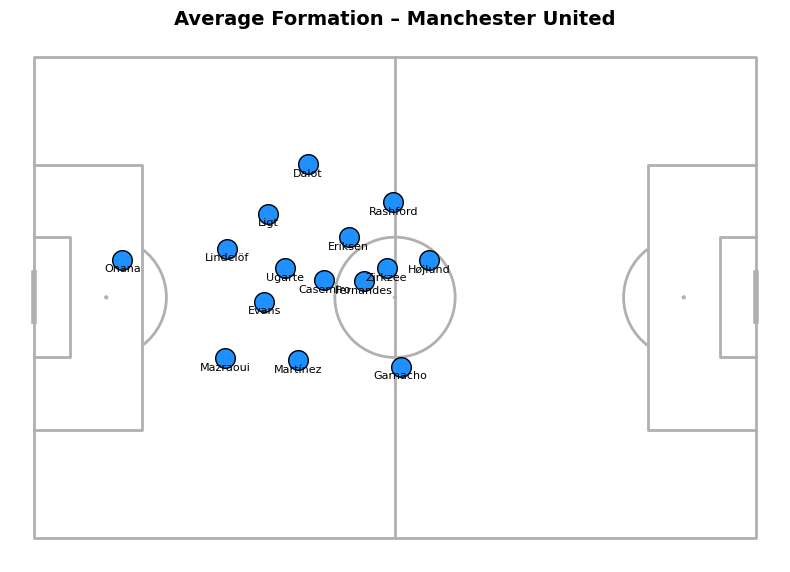

In [9]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

team_name = "Manchester United"  # 🔁 Try changing this!

# Filter out ball and rows with missing player names
formation = (
    df[(df["team_name"] == team_name) & (~df["is_ball"]) & (df["player_short_name"].notna())]
    .groupby("player_short_name")[["x_norm", "y_norm"]]
    .mean()
    .reset_index()
)

pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68)
fig, ax = pitch.draw(figsize=(8, 6))
pitch.scatter(formation["x_norm"], formation["y_norm"], s=200, c="dodgerblue", ax=ax, edgecolors="black", zorder=3)

for _, row in formation.iterrows():
    ax.text(row.x_norm, row.y_norm + 2, row.player_short_name.split()[-1], ha="center", fontsize=8)

ax.set_title(f"Average Formation – {team_name}", fontsize=14, weight="bold")
plt.show()

### 🧠 Step 2 — Cluster Possessions (Simplified)
We’ll group possessions by a few key features to see different **playing style patterns**.


In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Create possession_id by tracking changes in possession team
df_clean = df.copy()
df_clean['possession_team_change'] = (df_clean['in_possession_team'] != df_clean['in_possession_team'].shift()).astype(int)
df_clean['possession_id'] = df_clean['possession_team_change'].cumsum()

# Create simple possession features
df_pos = (
    df_clean[df_clean['in_possession_team'].notna()]
    .groupby(["match_id", "possession_id", "in_possession_team"])
    .agg({
        "x_norm": ["first", "last"],
        "frame": ["min", "max", "count"]
    })
    .reset_index()
)
df_pos.columns = ["match_id","possession_id","team_name","x_start","x_end","frame_start","frame_end","n_frames"]

# Derived features
df_pos["duration"] = df_pos["frame_end"] - df_pos["frame_start"]
df_pos["progress_x"] = df_pos["x_end"] - df_pos["x_start"]

# Filter out very short possessions
df_pos = df_pos[df_pos["duration"] > 5]

# Normalize + cluster
scaler = StandardScaler()
X = scaler.fit_transform(df_pos[["duration", "progress_x", "n_frames"]])

kmeans = KMeans(n_clusters=3, random_state=42)
df_pos["cluster"] = kmeans.fit_predict(X)

print(df_pos.groupby("cluster")[["duration","progress_x","n_frames"]].mean().round(2))

         duration  progress_x  n_frames
cluster                                
0           19.27      -40.96    462.30
1           16.50       11.21    402.17
2           58.39        5.63   1356.16


### 🎨 Step 3 — Visualize Possession Clusters


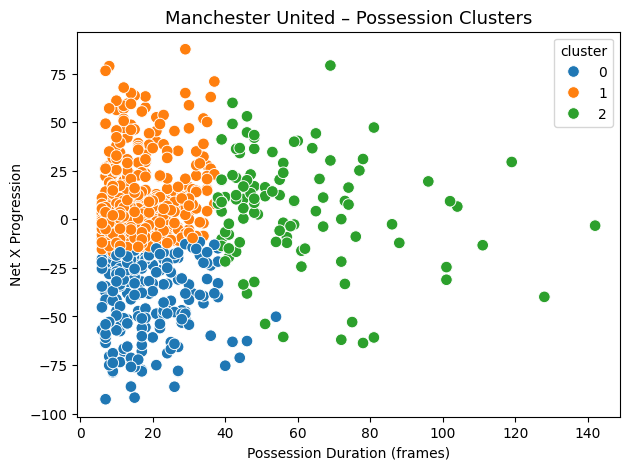

In [11]:
import seaborn as sns
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_pos, x="duration", y="progress_x", hue="cluster", palette="tab10", s=70)
plt.title(f"{team_name} – Possession Clusters", fontsize=13)
plt.xlabel("Possession Duration (frames)")
plt.ylabel("Net X Progression")
plt.show()


### 👥 Step 4 — Player Similarity (t-SNE Mini Map)
You’ll create a 2D map of players based on simple performance stats.


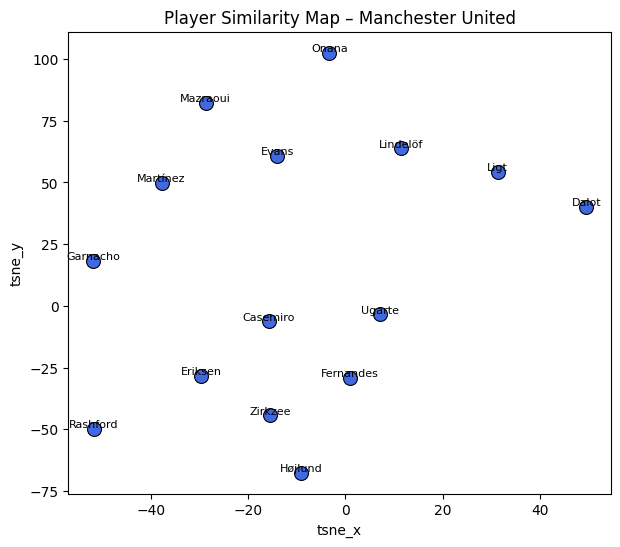

In [12]:
from sklearn.manifold import TSNE

# Simple player stats (filter out ball and None players)
player_summary = (
    df[(df["team_name"] == team_name) & (~df["is_ball"]) & (df["player_short_name"].notna())]
    .groupby("player_short_name")[["x_norm", "y_norm"]]
    .agg(["mean","std"])
)
player_summary.columns = ["x_mean","y_mean","x_std","y_std"]
player_summary = player_summary.fillna(0).reset_index()

# Run t-SNE
X_scaled = StandardScaler().fit_transform(player_summary[["x_mean","y_mean","x_std","y_std"]])
X_embedded = TSNE(n_components=2, random_state=42, perplexity=min(5, len(player_summary)-1)).fit_transform(X_scaled)
player_summary["tsne_x"], player_summary["tsne_y"] = X_embedded.T

# Plot
plt.figure(figsize=(7,6))
import seaborn as sns
sns.scatterplot(data=player_summary, x="tsne_x", y="tsne_y", s=100, color="royalblue", edgecolor="black")
for _, r in player_summary.iterrows():
    plt.text(r.tsne_x, r.tsne_y+0.5, r.player_short_name.split()[-1], ha="center", fontsize=8)
plt.title(f"Player Similarity Map – {team_name}")
plt.show()

## 🧩 Bonus Challenge

1. Try **a different team** — do they play more direct or build-up possessions?
2. Change the **number of clusters (n_clusters)** — how do the possession patterns change?
3. Identify the **most central player** in your formation and check if they’re also central in the t-SNE map.

---

🎓 *Congratulations — you just replicated the core parts of a professional football data analysis pipeline!*
